In [7]:
# IMPORT LIBRARIES

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

PROJECT_DIR = Path.cwd()

In [8]:
# CHECK DATASET

for split in ["train", "validation", "test"]:
    image_dir = PROJECT_DIR / "SunspotsYoloDataset" / split / "images"
    label_dir = PROJECT_DIR / "SunspotsYoloDataset"/ split / "labels"

    print(f"\n{split.upper()}")
    print("Images:", len(list(image_dir.glob("*.jpg"))))
    print("Labels:", len(list(label_dir.glob("*.txt"))))


TRAIN
Images: 1690
Labels: 1224

VALIDATION
Images: 380
Labels: 257

TEST
Images: 128
Labels: 108


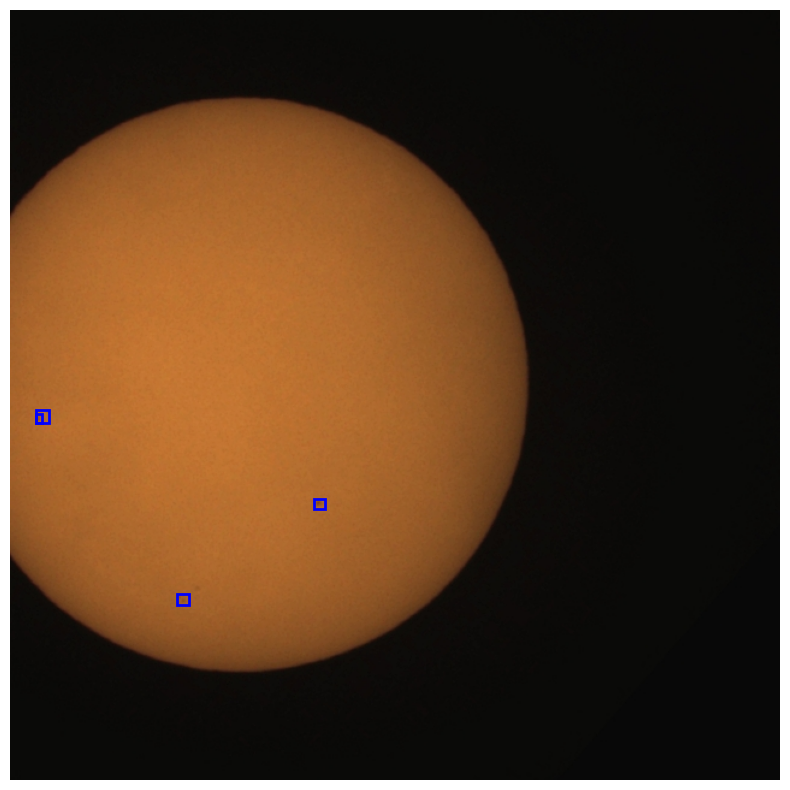

In [17]:
# CHECK ANNOTATIONS ON IMAGE

from src.dataset_utils import visualize_annotations

train_images= PROJECT_DIR / "SunspotsYoloDataset" / "train" / "images"
train_labels= PROJECT_DIR / "SunspotsYoloDataset"/ "train" / "labels"

valid_images= PROJECT_DIR / "SunspotsYoloDataset" / "valid" / "images"
valid_labels= PROJECT_DIR / "SunspotsYoloDataset"/ "valid" / "labels"

test_images= PROJECT_DIR / "SunspotsYoloDataset" / "test" / "images"
test_labels= PROJECT_DIR / "SunspotsYoloDataset"/ "test" / "labels"

image_files = sorted(train_images.glob("*.jpg"))
first_image = image_files[3]
first_label = train_labels / f"{first_image.stem}.txt"

visualize_annotations(first_image, first_label)

In [10]:
# create train dataset
from src.dataset import SunspotDataset

train_dataset= SunspotDataset(train_images, train_labels)
print(len(train_dataset))

image, target = train_dataset[0]
print(image.shape,"\n",target)

1690
torch.Size([3, 640, 640]) 
 {'boxes': tensor([[128.0000, 272.0003, 144.0000, 290.0003],
        [136.0000, 205.9997, 156.0000, 231.9997],
        [311.0000, 394.9997, 353.0000, 430.0000],
        [321.9997, 370.0000, 339.9997, 385.0003],
        [382.0000, 418.0003, 429.0003, 461.0000]]), 'labels': tensor([1, 1, 1, 1, 1])}


In [19]:
from torch.utils.data import DataLoader
from src.dataset import collate_fn

# create datasets
train_dataset= SunspotDataset(train_images, train_labels)

valid_dataset= SunspotDataset(valid_images, valid_labels)

test_dataset= SunspotDataset(test_images, test_labels)

# create dataloaders
train_loader= DataLoader(train_dataset,batch_size= 4, shuffle=True, collate_fn=collate_fn)

valid_loader= DataLoader(valid_dataset,batch_size= 4, shuffle=False, collate_fn=collate_fn)

test_loader= DataLoader(test_dataset,batch_size= 4, shuffle=False, collate_fn=collate_fn)

# test the DataLoader
images, targets = next(iter(train_loader))

print("Number of images:", len(images))
print("Number of targets:", len(targets))

print("First image shape:", images[0].shape)
print("First target:", targets[0])

Number of images: 4
Number of targets: 4
First image shape: torch.Size([3, 640, 640])
First target: {'boxes': tensor([[286.9997, 137.9997, 298.9997, 151.0000],
        [245.0000, 107.0000, 291.0000, 125.9997]]), 'labels': tensor([1, 1])}
